# Sheet 8 — Machine Learning (Solutions)

# 8.1 Optimal predictor and risk decomposition

## Part a

Since $\varepsilon \perp x$, the conditional expectation is
$$
h^\star(x) = \langle y \mid x \rangle = \langle x^2 + \varepsilon \mid x \rangle = x^2 + \langle \varepsilon \rangle = x^2.
$$
The irreducible noise (Eq. 7.10) is
$$
\sigma^2 = \langle \mathrm{Var}(y \mid x) \rangle_{f(x)} = \langle \mathrm{Var}(\varepsilon \mid x) \rangle_{f(x)} = \sigma_\varepsilon^2,
$$
since $\varepsilon$ is independent of $x$ with variance $\sigma_\varepsilon^2$.

## Part b

Expanding the squared loss and using $\langle \varepsilon \cdot g(x) \rangle = 0$ (independence and zero mean):
$$
R(h_{\boldsymbol{w}}) = \big\langle (x^2 - w_0 - w_1 x)^2 \big\rangle_{f(x)} + \sigma_\varepsilon^2.
$$
Expanding the square and inserting the given moments:
$$
= \langle x^4 \rangle - 2w_0\langle x^2 \rangle - 2w_1\langle x^3 \rangle + w_0^2 + 2w_0 w_1\langle x \rangle + w_1^2\langle x^2 \rangle + \sigma_\varepsilon^2
= 3 - 2w_0 + w_0^2 + w_1^2 + \sigma_\varepsilon^2.
$$
Setting partial derivatives to zero:
$$
\frac{\partial R}{\partial w_0} = -2 + 2w_0 = 0 \;\Longrightarrow\; w_0^\star = 1, \qquad
\frac{\partial R}{\partial w_1} = 2w_1 = 0 \;\Longrightarrow\; w_1^\star = 0.
$$
Thus $h_{\boldsymbol{w}^\star}(x) = 1$: the best affine predictor is the unconditional mean $\langle y \rangle_{f(x)} = \langle x^2 \rangle = 1$. The linear term contributes nothing because $h^\star(x) = x^2$ is even and $x$ is odd under $\mathcal{N}(0,1)$.

## Part c

The minimum risk is $R(h_{\boldsymbol{w}^\star}) = 3 - 2 + 1 + \sigma_\varepsilon^2 = 2 + \sigma_\varepsilon^2$.

The two-term decomposition (Eq. 7.9) gives:
- Irreducible noise: $\sigma^2 = \sigma_\varepsilon^2$.
- Approximation error: $\langle (h^\star(x) - h_{\boldsymbol{w}^\star}(x))^2 \rangle_{f(x)} = \langle (x^2 - 1)^2 \rangle = \langle x^4 \rangle - 2\langle x^2 \rangle + 1 = 3 - 2 + 1 = 2$.

Sum: $\sigma_\varepsilon^2 + 2 = R(h_{\boldsymbol{w}^\star})$. 

The approximation error equals $\mathrm{Var}_{f(x)}(h^\star(x)) = \mathrm{Var}_{f(x)}(x^2) = 2$: it measures how much the true function varies in directions the hypothesis class cannot represent. The affine class $\mathcal{H}$ cannot capture the curvature of $x^2$, so the fluctuations of $h^\star$ around its mean ($=1$) are entirely unrepresented by any $h_{\boldsymbol{w}} \in \mathcal{H}$.

# 8.2 Gradient of the logistic regression loss

## Part a

Writing $\mathrm{sig}(t) = (1 + e^{-t})^{-1}$ and differentiating:
$$
\frac{\mathrm{d}}{\mathrm{d}t}\,\mathrm{sig}(t) = \frac{e^{-t}}{(1+e^{-t})^2}
= \frac{1}{1+e^{-t}}\cdot\frac{e^{-t}}{1+e^{-t}}
= \mathrm{sig}(t)\,\bigl(1 - \mathrm{sig}(t)\bigr).
$$

## Part b

Let $u_i = \boldsymbol{w}^\top\boldsymbol{x}_i$ and $s_i = \mathrm{sig}(u_i) = h_{\boldsymbol{\theta}}(\boldsymbol{x}_i)$. Applying the chain rule to the $i$-th term in $\hat{\mathcal{L}}$:
$$
\frac{\partial}{\partial u_i}\left[-y_i\ln s_i - (1-y_i)\ln(1-s_i)\right] \cdot \frac{\mathrm{d}\,\mathrm{sig}}{\mathrm{d}t}\bigg|_{u_i}
= \left[-\frac{y_i}{s_i} + \frac{1-y_i}{1-s_i}\right]s_i(1-s_i).
$$
Simplifying:
$$
= -(y_i(1-s_i) - (1-y_i)s_i) = s_i - y_i.
$$
Since $\nabla_{\boldsymbol{w}}\,u_i = \boldsymbol{x}_i$, summing over all $i$ gives
$$
\nabla_{\boldsymbol{w}}\hat{\mathcal{L}}(\boldsymbol{w}) = \frac{1}{N}\sum_{i=1}^N \bigl(h_{\boldsymbol{\theta}}(\boldsymbol{x}_i) - y_i\bigr)\,\boldsymbol{x}_i. 
$$

## Part c

The gradient descent update is
$$
\boldsymbol{w} \leftarrow \boldsymbol{w} - \frac{\eta}{N}\sum_{i=1}^N \bigl(h_{\boldsymbol{\theta}}(\boldsymbol{x}_i) - y_i\bigr)\,\boldsymbol{x}_i.
$$
For example $i$ with $y_i = 0$ but $h_{\boldsymbol{\theta}}(\boldsymbol{x}_i) \approx 1$: the error $h_{\boldsymbol{\theta}}(\boldsymbol{x}_i) - y_i \approx 1$ is large and positive, so the update subtracts $\eta\,\boldsymbol{x}_i$ from $\boldsymbol{w}$. This decreases $\boldsymbol{w}^\top\boldsymbol{x}_i$ and hence $\mathrm{sig}(\boldsymbol{w}^\top\boldsymbol{x}_i)$, pulling the predicted probability towards 0 — the correct label. The gradient has the same "error $\times$ feature" form as least-squares regression, with the signed prediction error $h_{\boldsymbol{\theta}}(\boldsymbol{x}_i) - y_i$ playing the role of the residual.

# 8.3 Overfitting and the bias–variance tradeoff

True data-generating process:
$$
y_i = \sin(2\pi x_i) + \varepsilon_i,\qquad \varepsilon_i\sim\mathcal{N}(0,\,0.3^2),\qquad x_i\sim\mathrm{Unif}[0,1],\qquad\text{seed}=42.
$$

In [ ]:
import shutil
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial as P

fontsi  = 15   # tick labels, legend, annotations
fontsi2 = 20   # axis labels, suptitle

if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size':         fontsi,
    'axes.titlesize':    fontsi,
    'axes.labelsize':    fontsi2,
    'xtick.labelsize':   fontsi,
    'ytick.labelsize':   fontsi,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'legend.frameon':    False,
    'figure.dpi':        130,
})

# Load data
train = np.loadtxt('./data/sheet_8_data.txt')
test  = np.loadtxt('./data/sheet_8_test.txt')
x_tr, y_tr = train[:, 0], train[:, 1]
x_te, y_te = test[:, 0],  test[:, 1]

def fit_poly(x, y, k):
    """Fit degree-k polynomial; return coefficient vector."""
    return np.polyfit(x, y, k)

def predict_poly(coeffs, x):
    return np.polyval(coeffs, x)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)  2)

## Part a — Visual inspection

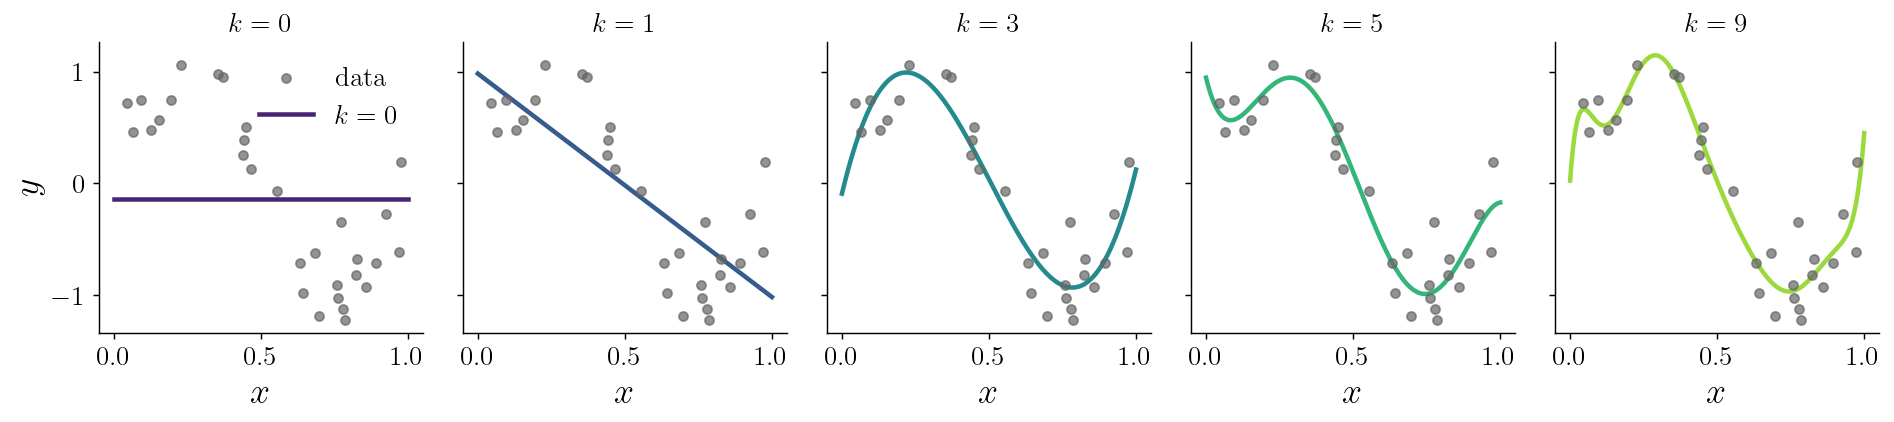

In [29]:
x_plot = np.linspace(0, 1, 300)
x_true = np.linspace(0, 1, 300)
y_true = np.sin(2 * np.pi * x_true)   # revealed in solution only

degrees = [0, 1, 3, 5, 9]
colors  = plt.cm.viridis(np.linspace(0.1, 0.85, len(degrees)))
fig, axes = plt.subplots(1, len(degrees), figsize=(15, 3.5), sharey=True)
for ax, k, c in zip(axes, degrees, colors):
    coeffs = fit_poly(x_tr, y_tr, k)
    ax.scatter(x_tr, y_tr, s=25, color='0.4', alpha=0.7, zorder=3, label='data')
    ax.plot(x_plot, predict_poly(coeffs, x_plot), color=c, lw=2.5, label=fr'$k={k}$')
    #ax.plot(x_true, y_true, 'k--', lw=1, label='truth')
    ax.set_title(fr'$k = {k}$', fontsize=fontsi)
    ax.set_xlabel(r'$x$', fontsize=fontsi2)
    ax.tick_params(labelsize=fontsi)
axes[0].set_ylabel(r'$y$', fontsize=fontsi2)
axes[0].legend(fontsize=fontsi, loc='upper right')
plt.tight_layout()
plt.savefig('sheet8_output/sheet_8_fit_overview.pdf', bbox_inches='tight')
plt.show()


## Part b — Training and test error vs. degree

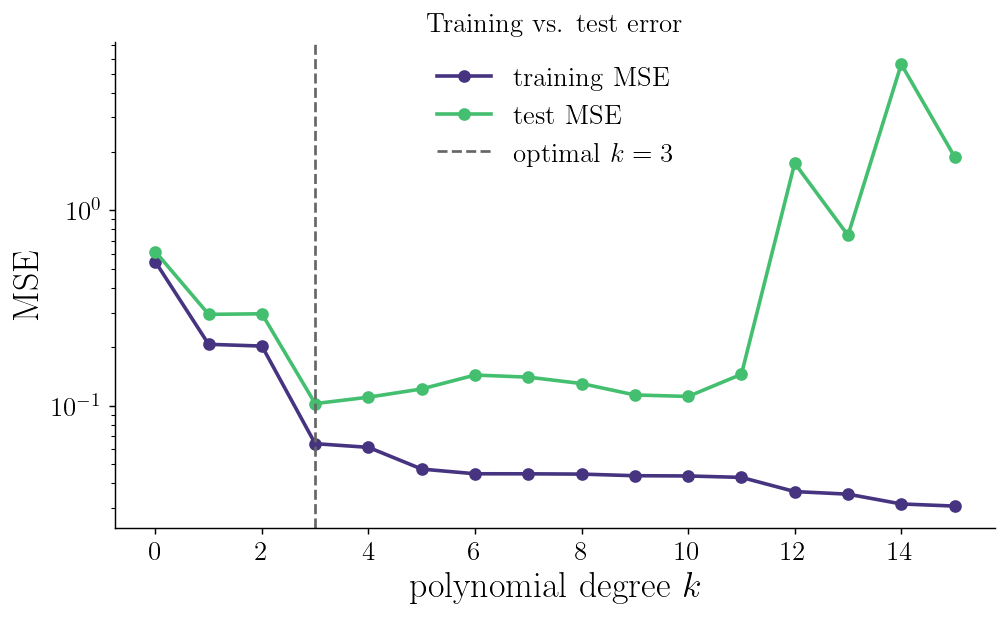

Optimal degree (min test MSE): k = 3


In [30]:
ks = np.arange(0, 16)
train_errs, test_errs = [], []
for k in ks:
    coeffs = fit_poly(x_tr, y_tr, k)
    train_errs.append(mse(y_tr, predict_poly(coeffs, x_tr)))
    test_errs.append(mse(y_te, predict_poly(coeffs, x_te)))

c_train, c_test = plt.cm.viridis([0.15, 0.7])
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, train_errs, 'o-', color=c_train, lw=2, label='training MSE')
ax.plot(ks, test_errs,  'o-', color=c_test,  lw=2, label='test MSE')
ax.axvline(ks[np.argmin(test_errs)], color='0.4', ls='--', lw=1.5,
           label=fr'optimal $k={ks[np.argmin(test_errs)]}$')
ax.set_xlabel(r'polynomial degree $k$', fontsize=fontsi2)
ax.set_ylabel(r'MSE', fontsize=fontsi2)
ax.set_yscale('log')
ax.tick_params(labelsize=fontsi)
ax.legend(fontsize=fontsi)
ax.set_title('Training vs. test error', fontsize=fontsi)
plt.tight_layout()
plt.savefig('sheet8_output/sheet_8_train_test_error.pdf', bbox_inches='tight')
plt.show()
print(f'Optimal degree (min test MSE): k = {ks[np.argmin(test_errs)]}')
# Training error decreases monotonically; test error is U-shaped.
# Left of minimum: high bias (model too rigid).
# Right of minimum: high variance (model chases noise).

## Part c — Bias–variance decomposition

In [ ]:
resamples = np.loadtxt('./data/sheet_8_resamples.txt')
set_ids = resamples[:, 0].astype(int)
x_re, y_re = resamples[:, 1], resamples[:, 2]

x0 = 0.5
nbhd = np.abs(x_te - x0) < 0.05
y0_bar  = y_te[nbhd].mean()        # proxy for h*(x0)
sigma2_hat = y_te[nbhd].var()      # estimate of irreducible noise

results = {}
for k in [1, 5, 9]:
    preds = []
    for sid in range(500):
        mask = set_ids == sid
        coeffs = fit_poly(x_re[mask], y_re[mask], k)
        preds.append(predict_poly(coeffs, x0))
    preds = np.array(preds)
    bias2 = (preds.mean() - y0_bar)  2
    var   = preds.var()
    # Expected squared error: average (y0 - h_hat(x0))^2 over test draws near x0
    exp_err = np.mean((preds - y0_bar)  2) + sigma2_hat
    results[k] = dict(bias2=bias2, var=var, sigma2=sigma2_hat,
                       sum=bias2+var+sigma2_hat, exp_err=exp_err)

print(f'sigma^2 estimate at x0={x0}: {sigma2_hat:.4f}  (true: 0.09)')
print(f'h*(x0) proxy: {y0_bar:.4f}  (true sin(pi) = {np.sin(2*np.pi*x0):.4f})')
print()
print(f'{"k":>3}  {"bias^2":>8}  {"var":>8}  {"sigma^2":>8}  {"sum":>8}  {"exp_err":>8}')
for k, r in results.items():
    print(f'{k:>3}  {r["bias2"]:>8.4f}  {r["var"]:>8.4f}  '
          f'{r["sigma2"]:>8.4f}  {r["sum"]:>8.4f}  {r["exp_err"]:>8.4f}')
# k=1: high bias, low variance; k=9: low bias, high variance; k=5: balanced.

sigma^2 estimate at x0=0.5: 0.1478  (true: 0.09)
h*(x0) proxy: -0.0578  (true sin(pi) = 0.0000)

  k    bias^2       var   sigma^2       sum   exp_err
  1    0.0030    0.0097    0.1478    0.1606    0.1606
  5    0.0030    0.0137    0.1478    0.1644    0.1644
  9    0.0026    0.0257    0.1478    0.1761    0.1761


## Part d — Effect of training set size (optional)

/opt/anaconda3/envs/test_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/test_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_97339/1619622690.py:34: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, k)
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_97339/1619622690.py:34: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, k)
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_97339/1619622690.py:34: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, k)
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_97339/1619622690.py:34: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, k)


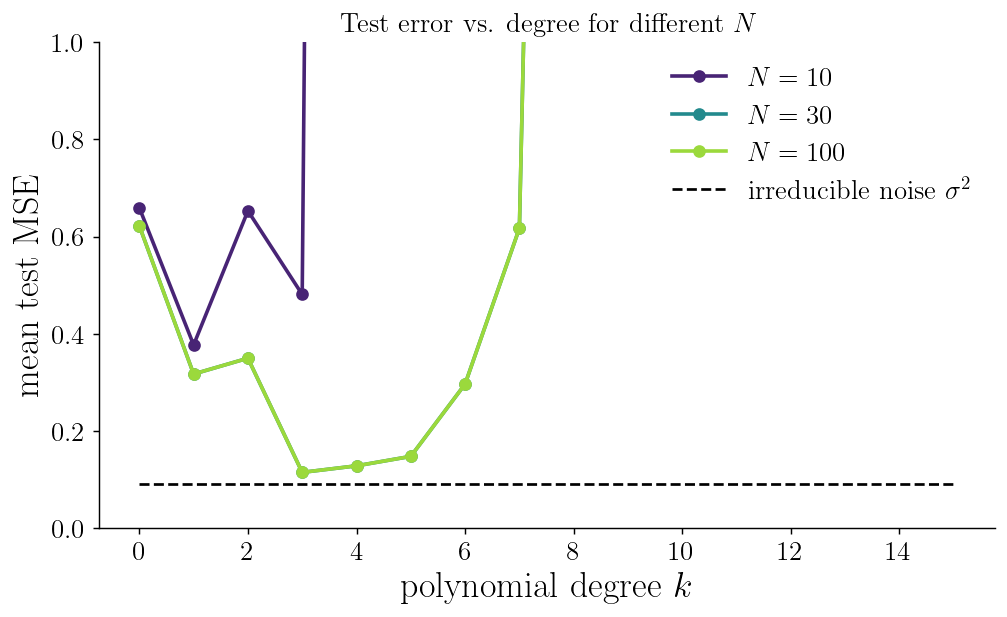

In [32]:
Ns     = [10, 30, 100]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(Ns)))
fig, ax = plt.subplots(figsize=(8, 5))
for N, c in zip(Ns, colors):
    test_errs_N = []
    for k in ks:
        errs = []
        for sid in range(min(500, 500)):
            mask = set_ids == sid
            xs, ys = x_re[mask][:N], y_re[mask][:N]
            if len(xs) < k + 1:
                continue
            coeffs = fit_poly(xs, ys, k)
            errs.append(mse(y_te, predict_poly(coeffs, x_te)))
        test_errs_N.append(np.mean(errs))
    ax.plot(ks, test_errs_N, 'o-', color=c, lw=2, label=fr'$N={N}$')
ax.plot(ks, [0.09] * len(ks), 'k--', lw=1.5, label=r'irreducible noise $\sigma^2$')
ax.set_xlabel(r'polynomial degree $k$', fontsize=fontsi2)
ax.set_ylabel(r'mean test MSE', fontsize=fontsi2)
ax.set_ylim(0, 1)
ax.tick_params(labelsize=fontsi)
ax.legend(fontsize=fontsi)
ax.set_title('Test error vs. degree for different $N$', fontsize=fontsi)
plt.tight_layout()
plt.savefig('sheet8_output/sheet_8_test_error_vs_N.pdf', bbox_inches='tight')
plt.show()
